# Ejercicio 1.
Genera una imagen semejante a una diana de tiro al blanco como se aprecia en la imagen a continuación
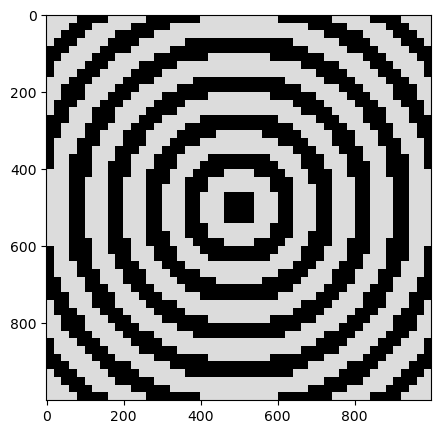


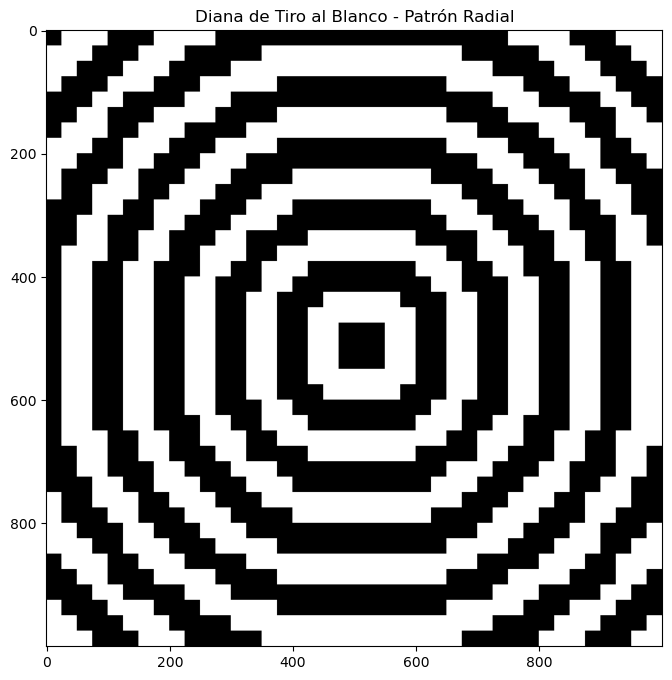

In [1]:
import numpy as np
import matplotlib.pyplot as plt

size = 1000
center = size // 2
block_size = 25 
stripe_width = 50 

x = np.arange(size) - center
y = np.arange(size) - center
X, Y = np.meshgrid(x, y)

X_blocked = (X // block_size) * block_size
Y_blocked = (Y // block_size) * block_size

distance = np.sqrt(X_blocked**2 + Y_blocked**2)

pattern = ((distance // stripe_width) % 2).astype(np.uint8) * 255

plt.figure(figsize=(8, 8))
plt.imshow(pattern, cmap='gray')
plt.title('Diana de Tiro al Blanco - Patrón Radial')
plt.show()

# Ejercicio 2.
Genera la imagen tal cual se muestra acontinuación, tomar en cuenta el tamaño 
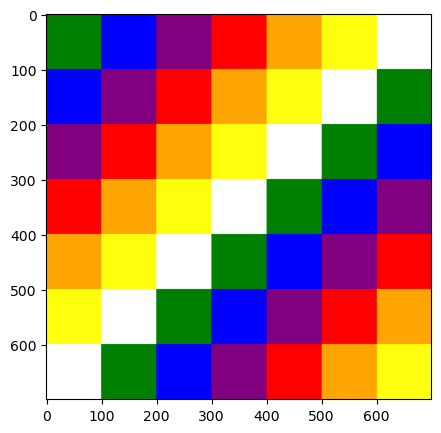

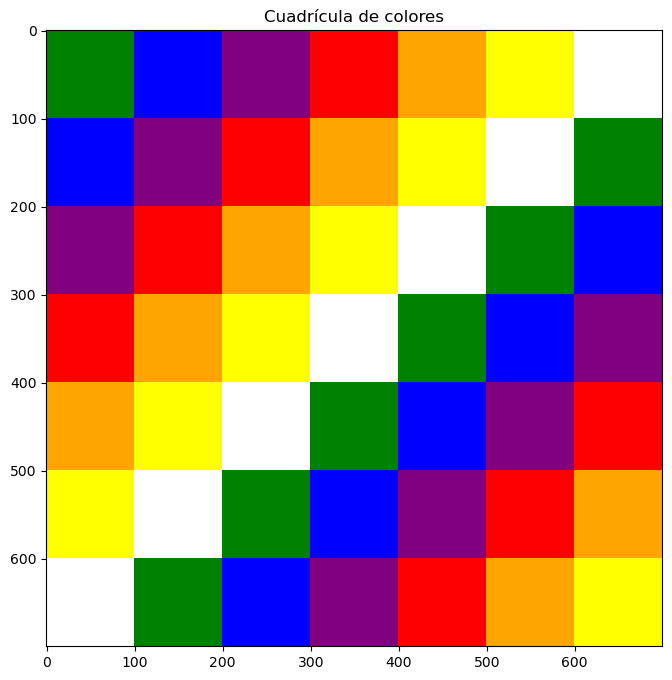

In [2]:
import numpy as np
import matplotlib.pyplot as plt

colores = [
    [0, 128, 0],
    [0, 0, 255],
    [128, 0, 128],
    [255, 0, 0],
    [255, 165, 0],
    [255, 255, 0],
    [255, 255, 255]
]

tamaño_celda = 100
filas = 7
columnas = 7
imagen = np.zeros((filas * tamaño_celda, columnas * tamaño_celda, 3), dtype=np.uint8)

for i in range(filas):
    for j in range(columnas):
        color_idx = (i + j) % 7
        y_inicio = i * tamaño_celda
        y_fin = (i + 1) * tamaño_celda
        x_inicio = j * tamaño_celda
        x_fin = (j + 1) * tamaño_celda
        imagen[y_inicio:y_fin, x_inicio:x_fin] = colores[color_idx]

plt.figure(figsize=(8, 8))
plt.imshow(imagen)
plt.title('Cuadrícula de colores')
plt.show()

# Ejercicio 3.
Tomando en cuenta la Bojack.jpg elige un punto de interés al azar (funcion randomica), solariza y posteriza la imagen, realiza un tratamiento de umbralización(el de preferencia), mezcla tecnicas y obtiene un filtro artistico,lista todas las imágenes con sus correspondientes titulos, guarda todas las imágenes resultantes con sus nombres.

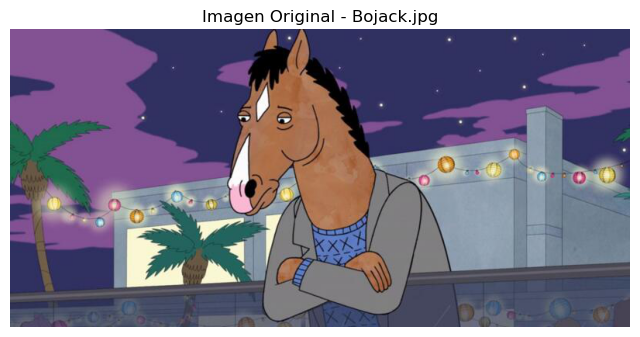

Guardada: Bojack_original.jpg


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageOps
import random

img = Image.open('Bojack.jpg')

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title('Imagen Original - Bojack.jpg')
plt.axis('off')
plt.show()

img.save('Bojack_original.jpg')
print("Guardada: Bojack_original.jpg")

Punto de interés aleatorio: (625, 151)


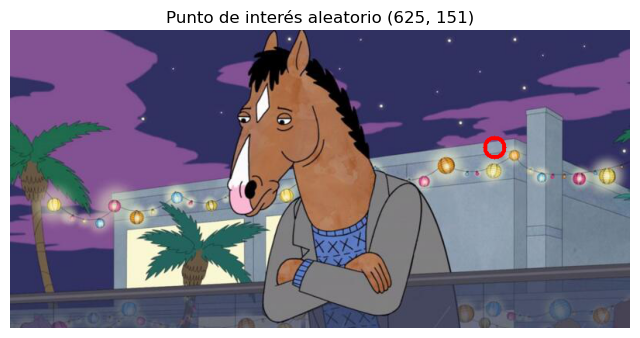

Guardada: Bojack_punto_interes.jpg


In [5]:
random.seed()
punto_x = random.randint(0, img.width - 1)
punto_y = random.randint(0, img.height - 1)
print(f"Punto de interés aleatorio: ({punto_x}, {punto_y})")

img_punto = img.copy()
img_punto_array = np.array(img_punto)

for dy in range(-15, 16):
    for dx in range(-15, 16):
        if 10 <= (dx**2 + dy**2)**0.5 <= 15:
            ny, nx = punto_y + dy, punto_x + dx
            if 0 <= ny < img.height and 0 <= nx < img.width:
                img_punto_array[ny, nx] = [255, 0, 0]
img_punto = Image.fromarray(img_punto_array)

plt.figure(figsize=(8, 6))
plt.imshow(img_punto)
plt.title(f'Punto de interés aleatorio ({punto_x}, {punto_y})')
plt.axis('off')
plt.show()

img_punto.save('Bojack_punto_interes.jpg')
print("Guardada: Bojack_punto_interes.jpg")

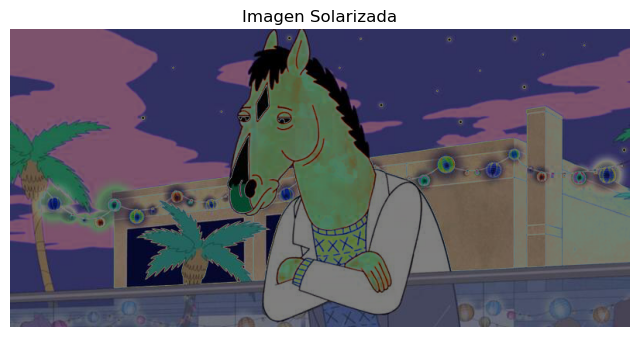

Guardada: Bojack_solarizada.jpg


In [6]:
img_solarizada = ImageOps.solarize(img, threshold=128)

plt.figure(figsize=(8, 6))
plt.imshow(img_solarizada)
plt.title('Imagen Solarizada')
plt.axis('off')
plt.show()

img_solarizada.save('Bojack_solarizada.jpg')
print("Guardada: Bojack_solarizada.jpg")

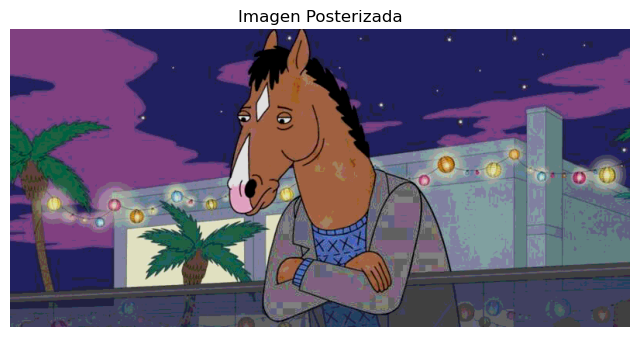

Guardada: Bojack_posterizada.jpg


In [7]:
img_posterizada = ImageOps.posterize(img, bits=3)

plt.figure(figsize=(8, 6))
plt.imshow(img_posterizada)
plt.title('Imagen Posterizada')
plt.axis('off')
plt.show()

img_posterizada.save('Bojack_posterizada.jpg')
print("Guardada: Bojack_posterizada.jpg")

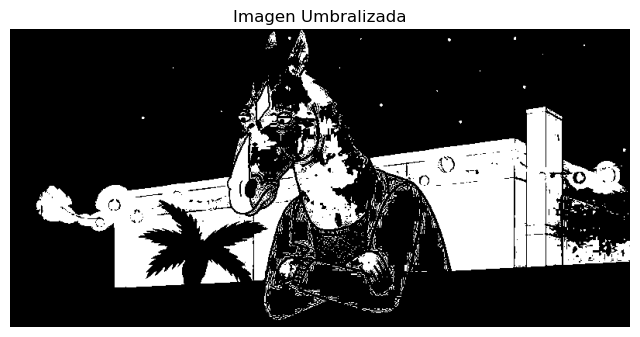

Guardada: Bojack_umbral.jpg


In [8]:
img_gris = img.convert('L')
umbral = 128
img_umbral = img_gris.point(lambda x: 255 if x > umbral else 0, '1')

plt.figure(figsize=(8, 6))
plt.imshow(img_umbral, cmap='gray')
plt.title('Imagen Umbralizada')
plt.axis('off')
plt.show()

img_umbral.save('Bojack_umbral.jpg')
print("Guardada: Bojack_umbral.jpg")

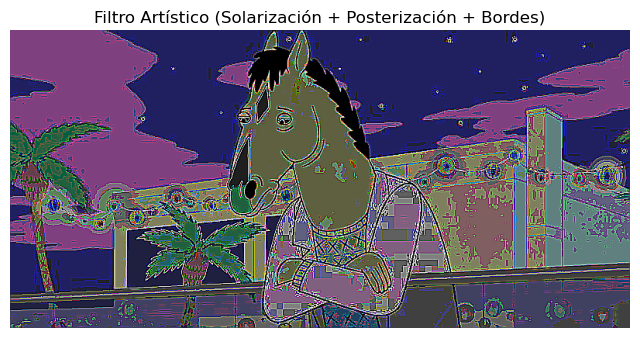

Guardada: Bojack_artistico.jpg


In [9]:
img_artistico = ImageOps.solarize(img_posterizada, threshold=100)
img_artistico = img_artistico.filter(ImageFilter.EDGE_ENHANCE_MORE)

plt.figure(figsize=(8, 6))
plt.imshow(img_artistico)
plt.title('Filtro Artístico (Solarización + Posterización + Bordes)')
plt.axis('off')
plt.show()

img_artistico.save('Bojack_artistico.jpg')
print("Guardada: Bojack_artistico.jpg")

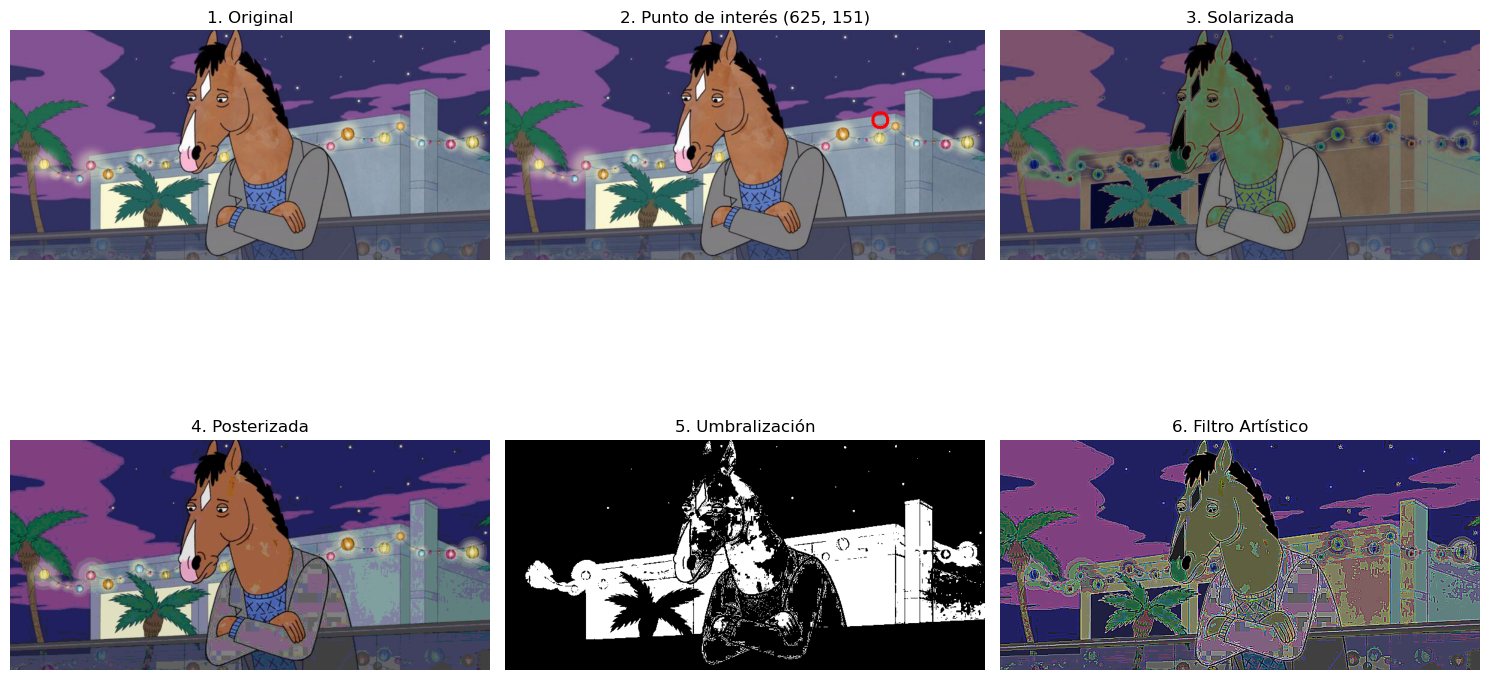


Todas las imágenes guardadas:
- Bojack_original.jpg
- Bojack_punto_interes.jpg
- Bojack_solarizada.jpg
- Bojack_posterizada.jpg
- Bojack_umbral.jpg
- Bojack_artistico.jpg


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(img)
axes[0, 0].set_title('1. Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_punto)
axes[0, 1].set_title(f'2. Punto de interés ({punto_x}, {punto_y})')
axes[0, 1].axis('off')

axes[0, 2].imshow(img_solarizada)
axes[0, 2].set_title('3. Solarizada')
axes[0, 2].axis('off')

axes[1, 0].imshow(img_posterizada)
axes[1, 0].set_title('4. Posterizada')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_umbral, cmap='gray')
axes[1, 1].set_title('5. Umbralización')
axes[1, 1].axis('off')

axes[1, 2].imshow(img_artistico)
axes[1, 2].set_title('6. Filtro Artístico')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("\nTodas las imágenes guardadas:")
print("- Bojack_original.jpg")
print("- Bojack_punto_interes.jpg")
print("- Bojack_solarizada.jpg")
print("- Bojack_posterizada.jpg")
print("- Bojack_umbral.jpg")
print("- Bojack_artistico.jpg")

# Ejercicio 4.
Genera un avatar, basandote en una imagen tuya que usaste en practicas anteriores, este avatar debe tener filtros y/o umbralizaciones.
Guarda la imagen 

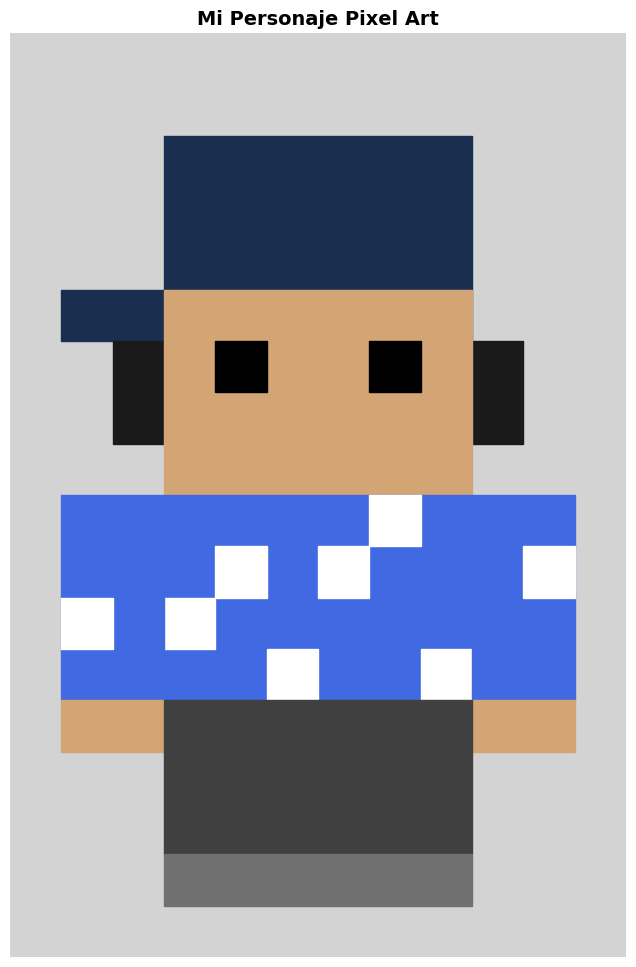

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(8, 12))
ax.set_xlim(0, 12)
ax.set_ylim(0, 18)
ax.set_aspect('equal')
ax.axis('off')

ax.add_patch(patches.Rectangle((0, 0), 12, 18, color='#D3D3D3'))

PIEL = '#D4A574'
OJOS = '#000000'
BLANCO = '#FFFFFF'
AZUL = '#4169E1'
AZUL_OSCURO = '#1A2F50'
PANTALON = '#404040'
ZAPATOS = '#707070'
NEGRO = '#1A1A1A'

ax.add_patch(patches.Rectangle((3, 12), 6, 4, color=AZUL_OSCURO)) 
ax.add_patch(patches.Rectangle((1, 12), 4, 1, color=AZUL_OSCURO))  


ax.add_patch(patches.Rectangle((2, 10), 2, 2, color=NEGRO)) 
ax.add_patch(patches.Rectangle((8, 10), 2, 2, color=NEGRO))  

ax.add_patch(patches.Rectangle((3, 9), 6, 4, color=PIEL))

ax.add_patch(patches.Rectangle((4, 11), 1, 1, color=OJOS))
ax.add_patch(patches.Rectangle((7, 11), 1, 1, color=OJOS))

ax.add_patch(patches.Rectangle((3, 5), 6, 4, color=AZUL))

ax.add_patch(patches.Rectangle((4, 7), 1, 1, color=BLANCO))
ax.add_patch(patches.Rectangle((7, 8), 1, 1, color=BLANCO))
ax.add_patch(patches.Rectangle((5, 5), 1, 1, color=BLANCO))
ax.add_patch(patches.Rectangle((3, 6), 1, 1, color=BLANCO))
ax.add_patch(patches.Rectangle((8, 5), 1, 1, color=BLANCO))
ax.add_patch(patches.Rectangle((6, 7), 1, 1, color=BLANCO))

ax.add_patch(patches.Rectangle((1, 5), 2, 4, color=AZUL))
ax.add_patch(patches.Rectangle((1, 6), 1, 1, color=BLANCO))
ax.add_patch(patches.Rectangle((9, 5), 2, 4, color=AZUL))
ax.add_patch(patches.Rectangle((10, 7), 1, 1, color=BLANCO)) 

ax.add_patch(patches.Rectangle((1, 4), 2, 1, color=PIEL))
ax.add_patch(patches.Rectangle((9, 4), 2, 1, color=PIEL))

ax.add_patch(patches.Rectangle((3, 2), 3, 3, color=PANTALON))
ax.add_patch(patches.Rectangle((6, 2), 3, 3, color=PANTALON))

ax.add_patch(patches.Rectangle((3, 1), 3, 1, color=ZAPATOS))
ax.add_patch(patches.Rectangle((6, 1), 3, 1, color=ZAPATOS))

ax.set_title('Mi Personaje Pixel Art', fontsize=14, fontweight='bold')
plt.savefig("mi_personaje_pixelart.png", dpi=150, bbox_inches='tight')
plt.show()

Umbralizacion binaria y binaria inversa

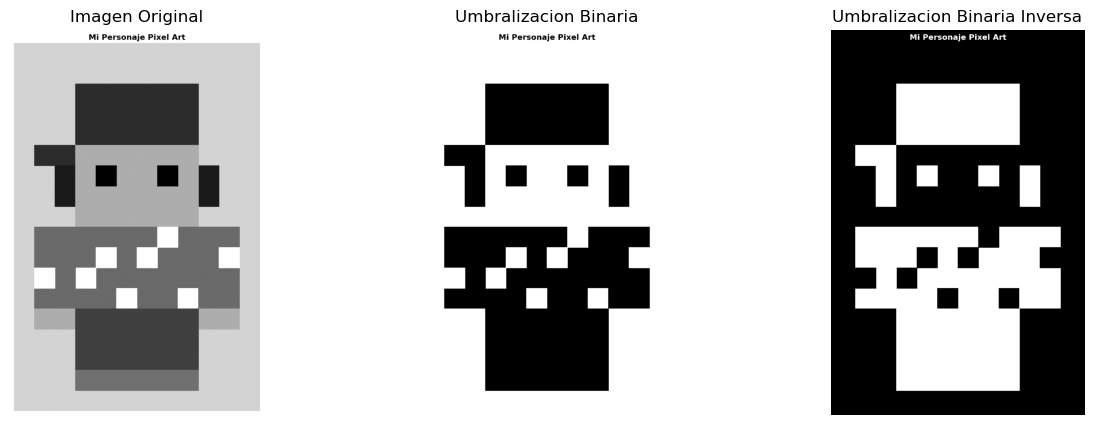

In [12]:
import cv2
import matplotlib.pyplot as plt
imagen = cv2.imread('mi_personaje_pixelart.png',0)
_,umbral_binario = cv2.threshold(imagen,127,255,cv2.THRESH_BINARY)

_,umbral_binaria_inv = cv2.threshold(imagen,127,255,cv2.THRESH_BINARY_INV)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(imagen,cmap='gray')
plt.title('Imagen Original')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(umbral_binario,cmap='gray')
plt.title('Umbralizacion Binaria')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(umbral_binaria_inv,cmap='gray')
plt.title('Umbralizacion Binaria Inversa')
plt.axis('off')
plt.show()

Umbralizacion OTSU

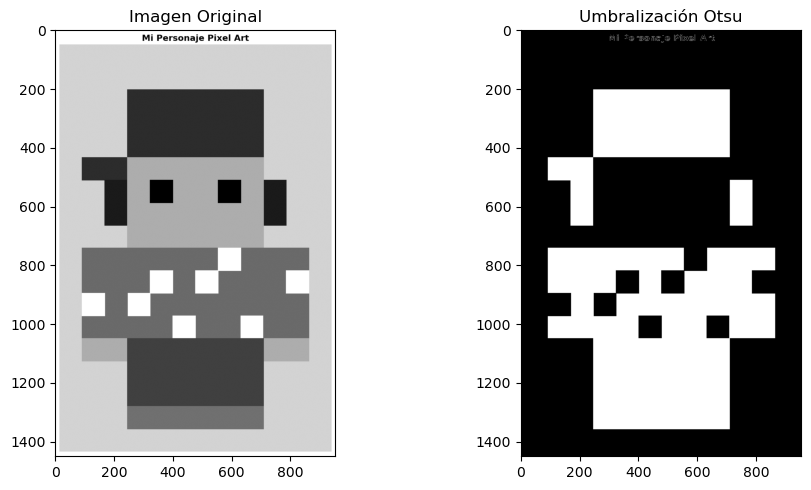

In [13]:
import cv2
from matplotlib import image
import numpy as np
import matplotlib.pyplot as plt

imagen=cv2.imread('mi_personaje_pixelart.png',0)
_,otsu=cv2.threshold(imagen,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
imagen_fin=np.where(imagen>otsu,255,0).astype(np.uint8)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(imagen,cmap='gray')
plt.subplot(1,2,2)
plt.title('Umbralización Otsu')
plt.imshow(imagen_fin,cmap='gray')
plt.tight_layout()
plt.show()

Aplicando filtros

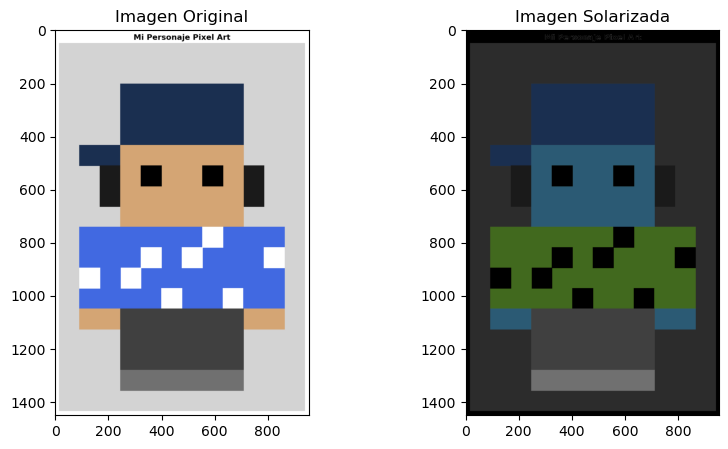

True

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def solarizar(imagen, umbral):
    #aplicamos sol
    img_sol = np.where(imagen<umbral,imagen,255-imagen )
    return img_sol

imagen = cv2.imread('mi_personaje_pixelart.png')
umbral = 127
img_fin = solarizar(imagen,umbral)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.subplot(1,3,2)
plt.title('Imagen Solarizada')
plt.imshow(cv2.cvtColor(img_fin, cv2.COLOR_BGR2RGB))
plt.show()

cv2.imwrite("mi_personaje_solarizado.png", img_fin)

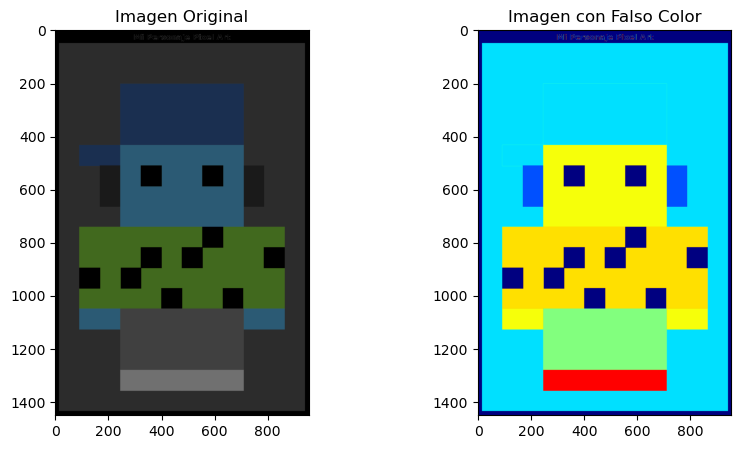

True

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def falso_color(img_gray):
    escal_img = cv2.normalize(img_gray, None, 0, 255, cv2.NORM_MINMAX)
    falso_img = cv2.applyColorMap(escal_img, cv2.COLORMAP_JET)
    return falso_img

imagen = cv2.imread('mi_personaje_solarizado.png')
img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
img_fin = falso_color(img_gray)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.subplot(1,2,2)
plt.title('Imagen con Falso Color')
plt.imshow(cv2.cvtColor(img_fin, cv2.COLOR_BGR2RGB))
plt.show()

cv2.imwrite("mi_personaje_falso_color.png", img_fin)

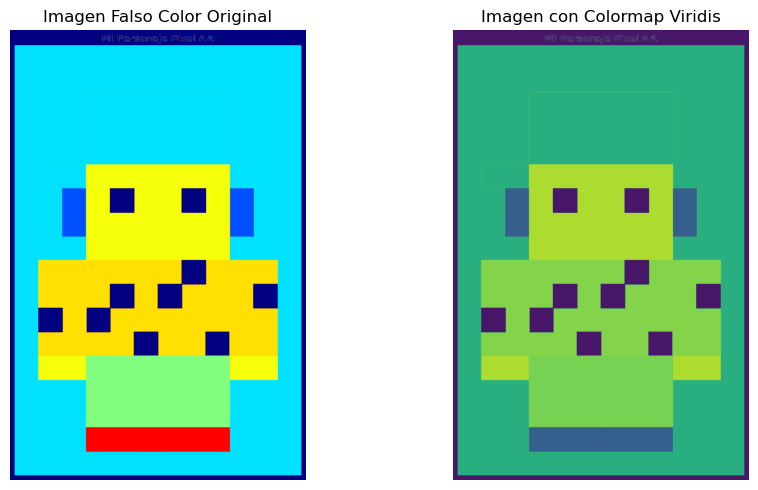

Guardada: mi_personaje_falso_color_viridis.png


In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_falso = cv2.imread('mi_personaje_falso_color.png')
img_gray = cv2.cvtColor(img_falso, cv2.COLOR_BGR2GRAY)

img_viridis = cv2.applyColorMap(img_gray, cv2.COLORMAP_VIRIDIS)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Imagen Falso Color Original')
plt.imshow(cv2.cvtColor(img_falso, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title('Imagen con Colormap Viridis')
plt.imshow(cv2.cvtColor(img_viridis, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.tight_layout()
plt.show()

cv2.imwrite("mi_personaje_falso_color_viridis.png", img_viridis)
print("Guardada: mi_personaje_falso_color_viridis.png")

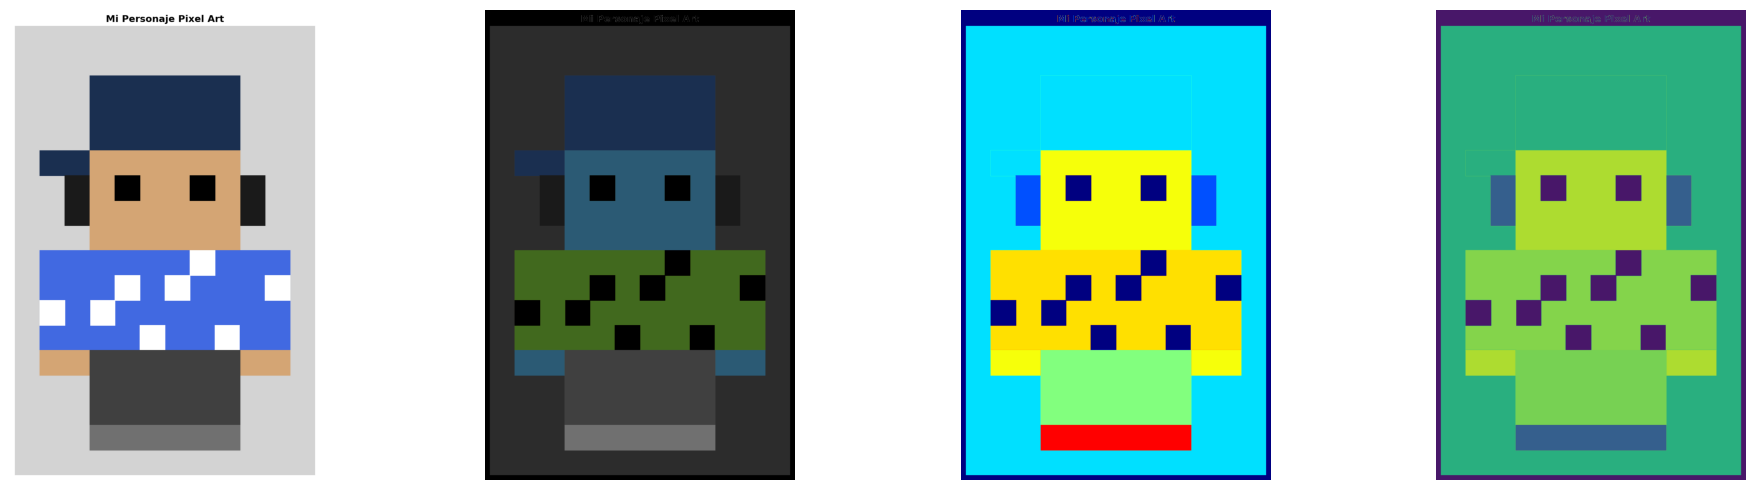

Guardada: resumen_imagenes.png


In [17]:
img_original = cv2.imread('mi_personaje_pixelart.png')
img_solarizado = cv2.imread('mi_personaje_solarizado.png')
img_falso_color = cv2.imread('mi_personaje_falso_color.png')
img_falso_color_viridis = cv2.imread('mi_personaje_falso_color_viridis.png')

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img_solarizado, cv2.COLOR_BGR2RGB))
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(img_falso_color, cv2.COLOR_BGR2RGB))
axes[2].axis('off')

axes[3].imshow(cv2.cvtColor(img_falso_color_viridis, cv2.COLOR_BGR2RGB))
axes[3].axis('off')

plt.tight_layout()
plt.savefig('resumen_imagenes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardada: resumen_imagenes.png")